# Parallel-plate capacitor in COMSOL

This notebook uses the [`mph`](https://mph.readthedocs.io/) Python bridge to launch COMSOL, build and solve a 3-D electrostatic model, and calculate capacitance.

The dielectric occupies $0<x<L_x$, $0<y<L_y$, and $0<z<d$. The lower face is grounded and the upper face is held at $V_0$. The side boundaries use COMSOL's default zero-charge condition, so this model represents an ideal capacitor without fringing.

Capacitance is extracted from electrostatic energy:

$$C_{\rm FEM}=\frac{2W_e}{V_0^2}, \qquad W_e=\int_\Omega \frac12\mathbf E\cdot\mathbf D\,d\Omega,$$

and checked against $C_{\rm exact}=\epsilon_0\epsilon_r L_xL_y/d$.

Requirements: local COMSOL Multiphysics plus the AC/DC Module, and `python -m pip install mph`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mph
from jpype.types import JInt

# mph.start() discovers a local COMSOL installation and starts a client.
# For an existing COMSOL Server, use mph.Client(port=<server_port>) instead.
client = mph.start()
print('COMSOL version:', client.version)

model = client.create('parallel_plate_capacitor')
j = model.java  # Direct access to COMSOL's documented Java API.


COMSOL version: 6.1


## 1. Parameters and geometry

COMSOL stores the units with each parameter. Coordinate-based box selections identify the electrode faces, avoiding fragile hard-coded boundary numbers.

In [2]:
parameters = {
    'Lx':   ('10[mm]', 'plate length'),
    'Ly':   ('10[mm]', 'plate width'),
    'd':    ('1[mm]',  'plate separation'),
    'epsr': ('4',      'relative permittivity'),
    'V0':   ('1[V]',   'applied voltage'),
}
for name, (value, description) in parameters.items():
    j.param().set(name, value, description)

j.component().create('comp1', True)
comp = j.component('comp1')
comp.geom().create('geom1', 3)
geom = comp.geom('geom1')
geom.lengthUnit('mm')
geom.create('blk1', 'Block')
geom.feature('blk1').set('base', 'corner')
geom.feature('blk1').set('pos', ['0', '0', '0'])
geom.feature('blk1').set('size', ['Lx', 'Ly', 'd'])
geom.run()

# Select z=0 and z=d faces with a tiny geometric tolerance.
tol = '1e-9[mm]'
for tag, z in [('bottom_plate', '0'), ('top_plate', 'd')]:
    comp.selection().create(tag, 'Box')
    sel = comp.selection(tag)
    # JInt avoids ambiguity between Java's set(String, int) and
    # set(String, boolean) overloads in COMSOL 6.1.
    sel.set('entitydim', JInt(2))
    sel.set('xmin', f'-{tol}'); sel.set('xmax', f'Lx+{tol}')
    sel.set('ymin', f'-{tol}'); sel.set('ymax', f'Ly+{tol}')
    sel.set('zmin', f'{z}-{tol}'); sel.set('zmax', f'{z}+{tol}')
    sel.set('condition', 'inside')

# Fail early if a coordinate selection did not find exactly one plate face.
bottom_ids = list(comp.selection('bottom_plate').entities(JInt(2)))
top_ids = list(comp.selection('top_plate').entities(JInt(2)))
print('Bottom electrode boundaries:', bottom_ids)
print('Top electrode boundaries   :', top_ids)
assert len(bottom_ids) == 1 and len(top_ids) == 1, (
    'Each electrode selection must contain exactly one boundary.'
)


Bottom electrode boundaries: [3]
Top electrode boundaries   : [4]


## 2. Dielectric, boundary conditions, and mesh

The material law is $\mathbf D=\epsilon_0\epsilon_r\mathbf E$. A voltage terminal and ground uniquely set the potential. The element sizes are tied to the plate gap because the gap is the smallest physically important length scale.

In [3]:
mat = comp.material().create('mat1', 'Common')
mat.label('Linear isotropic dielectric')
mat.propertyGroup('def').set(
    'relpermittivity',
    ['epsr', '0', '0', '0', 'epsr', '0', '0', '0', 'epsr'],
)

comp.physics().create('es', 'Electrostatics', 'geom1')
es = comp.physics('es')
es.create('gnd1', 'Ground', 2)
es.feature('gnd1').selection().named('bottom_plate')
es.create('term1', 'Terminal', 2)
es.feature('term1').selection().named('top_plate')
es.feature('term1').set('TerminalType', 'Voltage')
es.feature('term1').set('V0', 'V0')

comp.mesh().create('mesh1')
mesh = comp.mesh('mesh1')
mesh.create('ftet1', 'FreeTet')
mesh.feature('ftet1').create('size1', 'Size')
size = mesh.feature('ftet1').feature('size1')
size.set('custom', True)
size.set('hmax', 'd/2')
size.set('hmin', 'd/10')
mesh.run()


## 3. Solve and calculate capacitance

A stationary study solves $\nabla\cdot(\epsilon_0\epsilon_r\nabla V)=0$. COMSOL's `es.We` is the stored electrostatic energy density in J/m³. Integrating it over the dielectric gives $W_e$.

Stored energy       = 1.770837563e-12 J
COMSOL capacitance  = 3.541675127e-12 F = 3.541675 pF
Analytic capacitance= 3.541675127e-12 F = 3.541675 pF
Relative error      = +3.222e-12


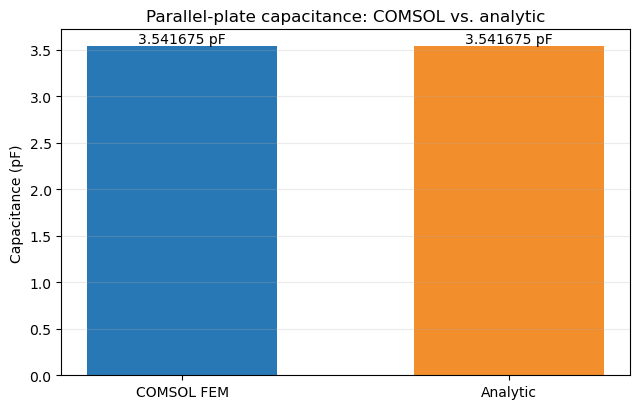

PASS: FEM and analytic values agree within 0.5%.


In [4]:
j.study().create('std1')
j.study('std1').create('stat', 'Stationary')
j.study('std1').run()

# Integrate field energy over every 3-D domain (there is one domain here).
j.result().numerical().create('intW', 'IntVolume')
intW = j.result().numerical('intW')
# COMSOL 6.1 may initialize a new derived-value selection as empty.
# Explicitly integrate over every dielectric domain.
intW.selection().all()
intW.set('expr', ['es.We'])
intW.set('unit', ['J'])
intW.set('descr', ['Stored electrostatic energy'])
W_J = float(np.asarray(intW.getReal()).squeeze())

V0_V = float(model.evaluate('V0', 'V'))
C_fem_F = 2.0 * W_J / V0_V**2
C_exact_F = float(model.evaluate('epsilon0_const*epsr*Lx*Ly/d', 'F'))
relative_error = (C_fem_F - C_exact_F) / C_exact_F

print(f'Stored energy       = {W_J:.9e} J')
print(f'COMSOL capacitance  = {C_fem_F:.9e} F = {C_fem_F*1e12:.6f} pF')
print(f'Analytic capacitance= {C_exact_F:.9e} F = {C_exact_F*1e12:.6f} pF')
print(f'Relative error      = {relative_error:+.3e}')

# Plot both values in pF on the same axis for a direct comparison.
labels = ['COMSOL FEM', 'Analytic']
values_pF = np.array([C_fem_F, C_exact_F]) * 1e12
colors = ['#2878B5', '#F28E2B']
fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(labels, values_pF, color=colors, width=0.58)
ax.set_ylabel('Capacitance (pF)')
ax.set_title('Parallel-plate capacitance: COMSOL vs. analytic')
ax.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, values_pF):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{value:.6f} pF', ha='center', va='bottom')
fig.tight_layout()
plt.show()

# Report validation without preventing later diagnostic/export cells from running.
if abs(relative_error) < 5e-3:
    print('PASS: FEM and analytic values agree within 0.5%.')
else:
    print('WARNING: discrepancy exceeds 0.5%; inspect selections and solution.')


## 4. Independent field checks and model export

The exact solution has $V(L_x/2,L_y/2,d/2)=V_0/2$ and $|\mathbf E|=V_0/d$. Sampling the numerical solution at the center provides two useful checks independent of the energy calculation.

In [5]:
# Interpolation coordinates use geom1's length unit (mm), not SI meters.
Lx_mm = float(model.evaluate('Lx', 'mm'))
Ly_mm = float(model.evaluate('Ly', 'mm'))
d_mm = float(model.evaluate('d', 'mm'))

# Save first, so an optional interpolation diagnostic cannot block export.
# This resolves correctly when Jupyter starts either at the repository root
# or in the directory containing this notebook.
repo_notebook_dir = Path.cwd() / 'Simulations' / 'trap_capacitance'
notebook_dir = repo_notebook_dir if repo_notebook_dir.is_dir() else Path.cwd()
output_file = notebook_dir / 'parallel_plate_capacitor.mph'
model.save(str(output_file))
print('Saved COMSOL model to:', output_file.resolve())

# Make this cell rerunnable by removing a previous interpolation feature.
try:
    j.result().numerical().remove('interp1')
except Exception:
    pass
j.result().numerical().create('interp1', 'Interp')
interp = j.result().numerical('interp1')
# The Electrostatics dependent potential is named V (not es.V).
# Derived field quantities such as normE do carry the es prefix.
interp.set('expr', ['V', 'es.normE'])
interp.set('coord', [[Lx_mm/2], [Ly_mm/2], [d_mm/2]])
center = np.asarray(interp.getReal(), dtype=float).reshape(-1)
V_center, E_center = center[0], center[1]
E_exact = float(model.evaluate('V0/d', 'V/m'))

print(f'Center potential = {V_center:.6g} V; expected {V0_V/2:.6g} V')
print(f'Center |E|      = {E_center:.6g} V/m; expected {E_exact:.6g} V/m')


Saved COMSOL model to: C:\Users\Administrator\Desktop\Yiyang_GITHUB\integrated_trapped_ions\Simulations\trap_capacitance\parallel_plate_capacitor.mph
Center potential = 0.5 V; expected 0.5 V
Center |E|      = 1000 V/m; expected 1000 V/m


## Expected result and physical limitations

For the default parameters, the analytic capacitance is approximately **3.5417 pF**. The FEM result should be extremely close because the insulating side walls impose the ideal one-dimensional field.

To include edge fringing, add a surrounding air domain substantially larger than the plates, represent the metal plates explicitly or as interior boundaries, and perform two convergence studies: refine the edge mesh and enlarge the air domain until capacitance changes by less than the required tolerance. The finite-plate capacitance will generally exceed the ideal formula because fringing fields store additional energy.